# 🔬 Spectral Map Reconstruction
Reads MicroManager OME-TIF files from a 2D XY stage scan, averages each image along Y (spatial rows),
and reconstructs a 2D map where each pixel contains the average intensity spectrum.

**Data format:** `<prefix>_MMStack_Posvoid<N>.ome.tif` — one file per stage position.

## 1. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os

# Point to wherever you cloned the repo on Drive
REPO_DIR = '/content/drive/My Drive/GoogleColab/2D Spectral mapping'
sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)  # also set working directory, fixes relative file paths inside notebooks


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Configuration
Set the path to your scan folder on Google Drive and the file prefix.

In [5]:
import os

# ── USER SETTINGS ────────────────────────────────────────────────────────────         # root of your Google Drive
SCAN_FOLDER  = 'test-scan_1'          # folder containing the .ome.tif files
FILE_PREFIX  = SCAN_FOLDER + '_MMStack_Posvoid'     # prefix before the position index
# ─────────────────────────────────────────────────────────────────────────────

DATA_DIR = os.path.join(REPO_DIR, SCAN_FOLDER)
print(f'Looking for data in: {DATA_DIR}')
print('Exists:', os.path.isdir(DATA_DIR))

Looking for data in: /content/drive/My Drive/GoogleColab/2D Spectral mapping/test-scan_1
Exists: True


## 3. Install / Import Dependencies

In [6]:
!pip install tifffile -q

In [7]:
import re
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from tqdm.notebook import tqdm

## 4. Load Metadata from the First File
MicroManager stores the full acquisition summary (grid size, stage positions, pixel dimensions)
inside every OME-TIF. We read it once from the first file.

In [8]:
def find_tif_files(data_dir, prefix):
    """Find all position .ome.tif files, sorted by their index number."""
    pattern = re.compile(rf'^{re.escape(prefix)}(\d*)\.ome\.tif$')
    files = {}
    for f in Path(data_dir).iterdir():
        m = pattern.match(f.name)
        if m:
            idx = int(m.group(1)) if m.group(1) else 0
            files[idx] = f
    return dict(sorted(files.items()))

tif_files = find_tif_files(DATA_DIR, FILE_PREFIX)
print(f'Found {len(tif_files)} position files.')
print('Index range:', min(tif_files), '→', max(tif_files))

# ── Read summary metadata from the first file ──────────────────────────────
first_file = list(tif_files.values())[0]
with tifffile.TiffFile(str(first_file)) as tif:
    mm_meta  = tif.micromanager_metadata
    summary  = mm_meta['Summary']
    img_width  = summary['Width']   # wavelength axis (X)
    img_height = summary['Height']  # spatial rows to average (Y)
    n_positions = summary['Positions']
    stage_positions = summary['StagePositions']

print(f'\nImage size per position: {img_width} px (wavelength) × {img_height} px (spatial rows)')
print(f'Total positions declared in metadata: {n_positions}')
print(f'Total positions found on disk:        {len(tif_files)}')

Found 144 position files.
Index range: 0 → 143

Image size per position: 640 px (wavelength) × 30 px (spatial rows)
Total positions declared in metadata: 144
Total positions found on disk:        144


## 5. Extract Stage XY Coordinates
We pull the physical XY stage position (in µm) for every scan point, then figure out
the unique X and Y grid values to determine the 2D map dimensions.

In [9]:
def get_xy_um(pos_entry):
    """Return (x_um, y_um) from a StagePositions entry."""
    for dev in pos_entry['DevicePositions']:
        if 'XY' in dev['Device'] or 'xy' in dev['Device'].lower():
            return tuple(dev['Position_um'][:2])
    raise ValueError(f"No XY device found in: {pos_entry}")

# Build coordinate list aligned to the file index
# Index 0  → file with no number suffix (Posvoid.ome.tif)
# Index N  → PosvoidN.ome.tif   (N maps to StagePositions[N])
coords = {}   # file_index → (x_um, y_um)
for file_idx in tif_files:
    pos_entry = stage_positions[file_idx]   # direct 1-to-1 mapping
    coords[file_idx] = get_xy_um(pos_entry)

all_x = sorted(set(round(v[0], 4) for v in coords.values()))
all_y = sorted(set(round(v[1], 4) for v in coords.values()))

n_cols = len(all_x)   # stage X  → map columns
n_rows = len(all_y)   # stage Y  → map rows

print(f'Grid: {n_rows} rows × {n_cols} cols  ({n_rows*n_cols} positions)')
print(f'Stage X range: {min(all_x):.3f} – {max(all_x):.3f} µm')
print(f'Stage Y range: {min(all_y):.3f} – {max(all_y):.3f} µm')

# Lookup: coordinate → row/col index in the map
x_to_col = {x: i for i, x in enumerate(all_x)}
y_to_row = {y: i for i, y in enumerate(all_y)}

Grid: 12 rows × 12 cols  (144 positions)
Stage X range: 35.880 – 38.080 µm
Stage Y range: 34.820 – 37.020 µm


## 6. Read Images and Build the Spectral Cube
For each position file:
1. Read the image `(height × width)` = `(Y_rows × wavelengths)`
2. Average along Y → spectrum of length `width`
3. Place it in the 3D array `spectral_cube[row, col, wavelength]`

In [14]:


print(np.shape(stack)[0])


144


In [15]:
spectral_cube = np.full((n_rows, n_cols, img_width), np.nan, dtype=np.float32)

#read data
stack = tifffile.imread(str(first_file))

for i in range(np.shape(stack)[0]):
  currentImg = stack[i]
  currentImg = currentImg.squeeze()
  x_um, y_um = coords[i]
  col = x_to_col[round(x_um, 4)]
  row = y_to_row[round(y_um, 4)]

  spectral_cube[row, col, :] = currentImg.mean(axis=0).astype(np.float32)

print(f'Spectral cube shape: {spectral_cube.shape}  (rows, cols, wavelength_px)')

Spectral cube shape: (12, 12, 640)  (rows, cols, wavelength_px)


## 7. Visualise the 2D Intensity Map
Integrate over all wavelengths to get a single intensity value per map pixel.

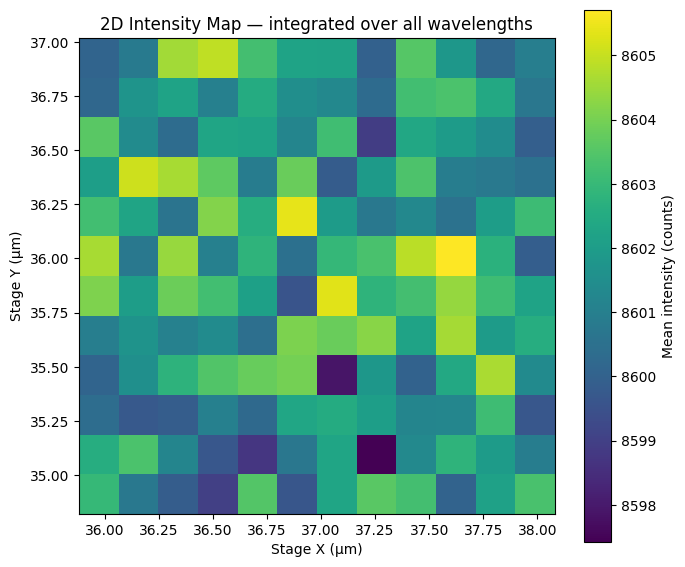

In [16]:
# ── Total (integrated) intensity map ─────────────────────────────────────────
intensity_map = np.nanmean(spectral_cube, axis=2)   # (n_rows, n_cols)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(
    intensity_map,
    origin='lower',
    extent=[min(all_x), max(all_x), min(all_y), max(all_y)],
    aspect='equal',
    cmap='viridis'
)
plt.colorbar(im, ax=ax, label='Mean intensity (counts)')
ax.set_xlabel('Stage X (µm)')
ax.set_ylabel('Stage Y (µm)')
ax.set_title('2D Intensity Map — integrated over all wavelengths')
plt.tight_layout()
plt.show()

## 8. Inspect Individual Spectra
Click any map pixel to see its spectrum, or use the sliders below.

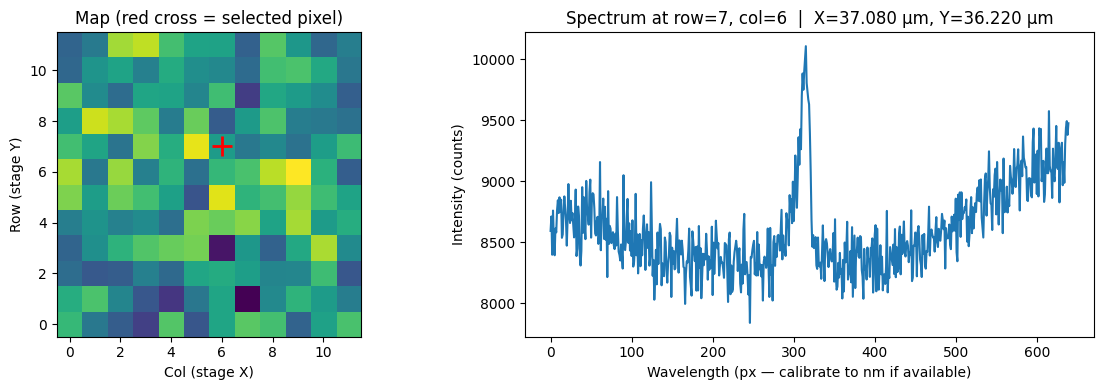

In [17]:
from ipywidgets import interact, IntSlider

pixel_x = np.arange(img_width)   # replace with real wavelengths if you have a calibration

@interact(
    row=IntSlider(min=0, max=n_rows-1, step=1, description='Map row'),
    col=IntSlider(min=0, max=n_cols-1, step=1, description='Map col')
)
def plot_spectrum(row, col):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: map with selected pixel highlighted
    axes[0].imshow(intensity_map, origin='lower', cmap='viridis')
    axes[0].plot(col, row, 'r+', markersize=14, markeredgewidth=2)
    axes[0].set_title('Map (red cross = selected pixel)')
    axes[0].set_xlabel('Col (stage X)')
    axes[0].set_ylabel('Row (stage Y)')

    # Right: spectrum at selected pixel
    spectrum = spectral_cube[row, col, :]
    axes[1].plot(pixel_x, spectrum, lw=1.5)
    axes[1].set_xlabel('Wavelength (px — calibrate to nm if available)')
    axes[1].set_ylabel('Intensity (counts)')
    axes[1].set_title(f'Spectrum at row={row}, col={col}  |  '
                      f'X={all_x[col]:.3f} µm, Y={all_y[row]:.3f} µm')
    plt.tight_layout()
    plt.show()

## 9. (Optional) Wavelength Calibration
If you have a dispersion calibration, enter the start wavelength and nm/px values here
to convert the X axis from pixels to nanometres.

In [18]:
# ── Fill in your calibration values (or leave as None to skip) ───────────────
WAVELENGTH_START_NM = None   # e.g. 400.0
NM_PER_PIXEL        = None   # e.g. 0.5
# ─────────────────────────────────────────────────────────────────────────────

if WAVELENGTH_START_NM is not None and NM_PER_PIXEL is not None:
    wavelengths_nm = WAVELENGTH_START_NM + np.arange(img_width) * NM_PER_PIXEL
    print(f'Wavelength range: {wavelengths_nm[0]:.1f} – {wavelengths_nm[-1]:.1f} nm')
else:
    wavelengths_nm = np.arange(img_width)   # fallback: pixel index
    print('No calibration set — using pixel index as wavelength axis.')

No calibration set — using pixel index as wavelength axis.


## 10. (Optional) Band-Integrated Map
Plot a 2D map integrated over a specific wavelength (pixel) range — useful for
highlighting a particular spectral feature.

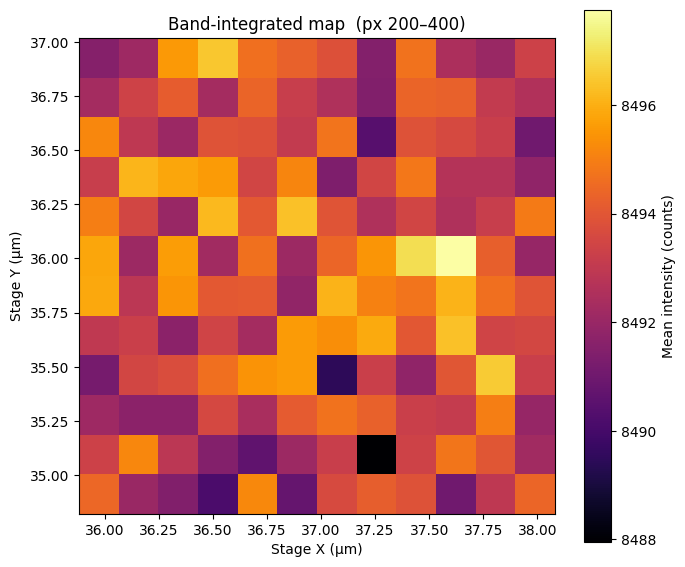

In [19]:
# ── Set wavelength (pixel) range to integrate ────────────────────────────────
BAND_START_PX = 200    # start pixel
BAND_END_PX   = 400    # end pixel
# ─────────────────────────────────────────────────────────────────────────────

band_map = np.nanmean(spectral_cube[:, :, BAND_START_PX:BAND_END_PX], axis=2)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(
    band_map,
    origin='lower',
    extent=[min(all_x), max(all_x), min(all_y), max(all_y)],
    aspect='equal',
    cmap='inferno'
)
plt.colorbar(im, ax=ax, label='Mean intensity (counts)')
ax.set_xlabel('Stage X (µm)')
ax.set_ylabel('Stage Y (µm)')
ax.set_title(f'Band-integrated map  (px {BAND_START_PX}–{BAND_END_PX})')
plt.tight_layout()
plt.show()

## 11. Save Results
Save the spectral cube as a NumPy `.npz` archive back to Drive for later use.

In [ ]:
output_path = os.path.join(DATA_DIR, 'spectral_cube.npz')

np.savez(
    output_path,
    spectral_cube = spectral_cube,   # (n_rows, n_cols, n_wavelengths)
    intensity_map = intensity_map,   # (n_rows, n_cols)
    stage_x_um    = np.array(all_x),
    stage_y_um    = np.array(all_y),
    wavelengths   = wavelengths_nm,
)
print(f'Saved to: {output_path}')